In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d

init = np.array([
    [0.7, 0.9],
    [0.8, 0.9],
    [0.4, 0.2],
    [0.1, 0.5],
    [0.3996, 0.1390], 
    [0.3036,  0.1536], 
    [0.978, 0.9703], 
    [0.9204, 0.586]
    
])

In [2]:
random_generator = np.random.RandomState(42)

def generate_random_models(n, nd):
    return random_generator.random_sample((n, nd))
def rosenbrock(params, a=1, b=100):
    x = params[:, 0]
    y = params[:, 1]
    return np.log10((a - x) ** 2 + b * (y - x**2) ** 2)

lb = np.array([0, 0])
ub = np.array([1.2, 1.2])
background = lb + (ub - lb) * generate_random_models(50000, 2)
mfits = rosenbrock(background)

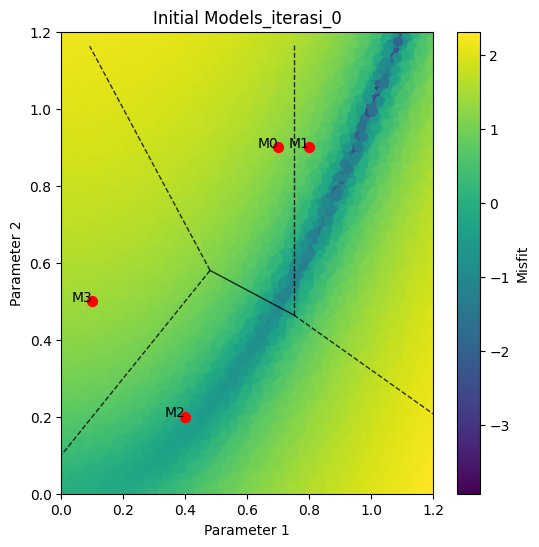

In [6]:
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d

fig, ax = plt.subplots(figsize=(6,6))

# background models
sc = ax.scatter(background[:, 0], background[:, 1],
                c=mfits, cmap='viridis', alpha=1)

# init models
ax.scatter(init[:, 0], init[:, 1], color='red', s=50)

# voronoi
vor = Voronoi(init)
voronoi_plot_2d(vor, ax=ax,
                show_vertices=False,
                line_colors='black',
                line_width=1,
                line_alpha=0.8,
                point_size=0)

# label titik init
for i, (x, y) in enumerate(init):
    ax.text(x, y, f"M{i}", fontsize=10, ha='right')

ax.set_xlabel('Parameter 1')
ax.set_ylabel('Parameter 2')
ax.set_title('Initial Models_iterasi_0')

ax.set_xlim(0, 1.2)
ax.set_ylim(0, 1.2)

fig.colorbar(sc, label='Misfit')

plt.show()